# 🧩 Keras 3 Overview — One High-Level API on Top of PyTorch, JAX, or TensorFlow

> **What you'll learn:** what Keras 3 is and where TensorFlow stands today, the three ways to build models, `compile`/`fit`/`evaluate`, callbacks, preprocessing layers, backend-agnostic custom layers and losses with `keras.ops`, saving in the `.keras` format, and how the same model looks in Keras vs PyTorch — ending with a Fashion-MNIST image classifier.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate |
| **Time** | ~2 hours to read and run, +1 hour for exercises and the project |
| **Prerequisites** | [PyTorch](02_PyTorch.ipynb) (tensors, `nn.Module`, training loops) |
| **Tested with** | Python 3.12 · keras 3.15 on the **PyTorch 2.14 backend** (TensorFlow not installed) |
| **Interview relevance** | ⭐ Low–Medium — **optional notebook**: PyTorch dominates AI/ML interviews, but Keras shows up at Google-ecosystem teams and in questions about callbacks, early stopping, saving formats, and writing custom layers/losses |

> 📌 **Optional:** skim this notebook if you are short on time. Everything important for interviews about deep learning is also covered in the PyTorch notebooks; this one teaches the Keras way of doing the same things.

## 🤔 What Is Keras 3?

**Keras** is a high-level deep-learning API: you describe layers, call `fit`, and Keras writes the training loop for you.

**Keras 3** (released November 2023) is a full rewrite that is **multi-backend**: the same Keras code runs on top of **JAX**, **TensorFlow**, or **PyTorch** (plus OpenVINO for inference only). You pick the backend with one environment variable before importing Keras.

Everyday analogy — a **universal TV remote**: the buttons (`Dense`, `fit`, `evaluate`, `save`) stay the same, and the remote talks to whichever TV (backend) you point it at.

```
           your model code (keras.layers, keras.ops, fit/evaluate)
                                │
           ┌────────────────────┼─────────────────────┐
         JAX                TensorFlow              PyTorch   ← chosen with KERAS_BACKEND
```

In this course TensorFlow is **not installed**, so we run Keras on the **PyTorch** backend.

## 🎯 Why It Matters

- **Fast prototyping.** A working, well-structured training run (validation, early stopping, checkpoints) takes a dozen lines.
- **Where TensorFlow stands today (honest version):** most new research and open-source LLM code is written in **PyTorch**, and Google/DeepMind research leans on **JAX**. TensorFlow is still deployed in many companies — especially through **TF Serving** (server inference), **LiteRT** (formerly TensorFlow Lite, for phones and edge devices), and **TensorFlow.js** (in the browser). Keras 3 lets one codebase target those runtimes while training on the backend you prefer.
- **Transferable ideas.** Callbacks, early stopping, preprocessing inside the model, and serialization exist in every framework — interviewers ask about them regardless of the library.
- **In interviews** Keras questions are usually conceptual: *Sequential vs Functional vs subclassing*, *how early stopping avoids overfitting*, *how to save a model with custom layers*, *`from_logits` bugs*, and *implementing a custom loss such as focal loss correctly*.

## ✅ By the End You Can

- [ ] Choose a Keras backend and write backend-agnostic math with `keras.ops`
- [ ] Build the same model with the Sequential, Functional, and subclassing APIs
- [ ] Train with `compile`/`fit`, early stopping, checkpoints, and learning-rate schedules on a proper validation split
- [ ] Put preprocessing and augmentation inside the model
- [ ] Implement a custom `Dense` layer and a correct binary focal loss, verified against Keras built-ins
- [ ] Save and reload models in the `.keras` format, and translate a model between Keras and PyTorch

## 📋 Table of Contents

1. [Backends and keras.ops](#1.-Backends-and-keras.ops-🟢)
2. [Three Ways to Build a Model](#2.-Three-Ways-to-Build-a-Model-🟢)
3. [compile, fit, evaluate, predict](#3.-compile,-fit,-evaluate,-predict-🟢)
4. [Callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau](#4.-Callbacks:-EarlyStopping,-ModelCheckpoint,-ReduceLROnPlateau-🟡)
5. [Preprocessing Layers](#5.-Preprocessing-Layers-🟡)
6. [Backend-Agnostic Custom Layers and Losses](#6.-Backend-Agnostic-Custom-Layers-and-Losses-🟡)
7. [Saving and Loading with .keras](#7.-Saving-and-Loading-with-.keras-🟢)
8. [The Same Model in Keras vs PyTorch](#8.-The-Same-Model-in-Keras-vs-PyTorch-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Fashion-MNIST-Classifier-With-Callbacks) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

**The backend must be chosen before `import keras`** — after the import it can't be changed in the same Python process. Run the cell below first; if Keras is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "keras>=3.5" "torch>=2.3" numpy matplotlib

import os

os.environ["KERAS_BACKEND"] = "torch"          # "jax" or "tensorflow" also work when those packages are installed

import sys
import time
import warnings
import zipfile
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import torch
from keras import layers, ops

print(f"Python {sys.version.split()[0]} | keras {keras.__version__} | backend: {keras.config.backend()} | torch {torch.__version__}")

keras.utils.set_random_seed(42)                 # seeds Python, NumPy and the backend in one call
OUTPUT_DIR = Path("_outputs")                   # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)


def to_np(value):
    """Backend tensors / Keras variables → NumPy; anything else through np.asarray."""
    if torch.is_tensor(value) or isinstance(value, keras.Variable):
        return ops.convert_to_numpy(value)
    return np.asarray(value)


def check(name, got, expected, hint="", atol=1e-5):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    got_arr, exp_arr = to_np(got), to_np(expected)
    if got_arr.shape != exp_arr.shape:
        raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
    numeric = np.issubdtype(exp_arr.dtype, np.number) and exp_arr.dtype != bool
    ok = np.allclose(got_arr.astype(np.float64), exp_arr.astype(np.float64), atol=atol) if numeric else np.array_equal(got_arr, exp_arr)
    assert ok, f"❌ {name}: values are not quite right. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | keras 3.15.1 | backend: torch | torch 2.14.0


## 1. Backends and keras.ops 🟢

`keras.ops` is a NumPy-like set of math functions (`ops.matmul`, `ops.softmax`, `ops.where`, …) that **every backend implements**. Code written with `keras.ops` runs unchanged on JAX, TensorFlow, or PyTorch. On the PyTorch backend, the results are ordinary `torch.Tensor`s on the default device (Apple MPS here if available).

In [2]:
x = ops.convert_to_tensor([[1.0, 2.0], [3.0, 4.0]])
print("type:", type(x).__name__, "| device:", x.device)
print("matmul(x, xᵀ):\n", ops.matmul(x, ops.transpose(x)))
print("softmax per row:\n", ops.softmax(x, axis=-1))
print("random normal (seeded):\n", keras.random.normal((2, 3), seed=0))

demo_model = keras.Sequential([keras.Input(shape=(4,)), layers.Dense(2)])
print("\nA Keras model on this backend is a torch.nn.Module:", isinstance(demo_model, torch.nn.Module))
print("its trainable tensors as PyTorch sees them:", [tuple(p.shape) for p in demo_model.parameters()])

type: Tensor | device: mps:0
matmul(x, xᵀ):
 tensor([[ 5., 11.],
        [11., 25.]], device='mps:0')
softmax per row:
 tensor([[0.2689, 0.7311],
        [0.2689, 0.7311]], device='mps:0')
random normal (seeded):
 tensor([[-0.2345, -0.4574,  0.8833],
        [-0.4264, -0.1448,  0.0979]], device='mps:0')

A Keras model on this backend is a torch.nn.Module: True
its trainable tensors as PyTorch sees them: [(2,), (4, 2)]


### ✍️ Your Turn

Using only `keras.ops`, compute the softmax of `[1.0, 2.0, 3.0]`.

In [3]:
logits_turn = ops.convert_to_tensor([1.0, 2.0, 3.0])
softmax_turn = None  # TODO: your code here
check("softmax_turn", softmax_turn, [0.09003057, 0.24472847, 0.66524096], hint="ops.softmax(logits_turn)")

⏳ softmax_turn: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
logits_turn = ops.convert_to_tensor([1.0, 2.0, 3.0])
softmax_turn = ops.softmax(logits_turn)
check("softmax_turn", softmax_turn, [0.09003057, 0.24472847, 0.66524096])
```
By hand: `ops.exp(logits_turn) / ops.sum(ops.exp(logits_turn))` gives the same numbers.
</details>

> 💡 **Interview angle:** "How can Keras 3 run on three frameworks?" — layers, losses and metrics are written against `keras.ops`, a common op set each backend implements; the backend is picked with `KERAS_BACKEND` before import. Code that calls `torch.*` or `tf.*` directly inside a layer silently loses that portability.

## 2. Three Ways to Build a Model 🟢

| API | Looks like | Use when |
|---|---|---|
| **Sequential** | a list of layers | a plain stack, one input, one output |
| **Functional** | calling layers on symbolic `keras.Input` tensors | multiple inputs/outputs, skip connections, shared layers — still inspectable (`summary`, plotting) |
| **Subclassing** | a `keras.Model` class with `call()` | custom control flow; most flexible, like a PyTorch `nn.Module` |

We build the same 784 → 128 → 10 network all three ways.

In [4]:
def make_sequential():
    return keras.Sequential([
        keras.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(10),                                   # raw scores (logits)
    ], name="sequential_mlp")


def make_functional():
    inputs = keras.Input(shape=(784,))
    hidden = layers.Dense(128, activation="relu")(inputs)
    outputs = layers.Dense(10)(hidden)
    return keras.Model(inputs, outputs, name="functional_mlp")


class SubclassedMLP(keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.hidden = layers.Dense(128, activation="relu")
        self.out = layers.Dense(10)

    def call(self, inputs, training=False):
        return self.out(self.hidden(inputs))


models_3 = {"Sequential": make_sequential(), "Functional": make_functional(), "Subclassed": SubclassedMLP()}
models_3["Subclassed"](np.zeros((1, 784), dtype="float32"))          # subclassed models are built on first call
for name, m in models_3.items():
    print(f"{name:10s}: {m.count_params():,} parameters")
assert len({m.count_params() for m in models_3.values()}) == 1
models_3["Functional"].summary()

Sequential: 101,770 parameters
Functional: 101,770 parameters
Subclassed: 101,770 parameters


Model: "functional_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

The **Functional API** shines when data has more than one input — e.g. an image plus a numeric feature:

In [5]:
image_in = keras.Input(shape=(28, 28, 1), name="image")
price_in = keras.Input(shape=(1,), name="price")
image_features = layers.Flatten()(layers.Conv2D(8, 3, activation="relu")(image_in))
merged = layers.Concatenate()([image_features, price_in])
two_input = keras.Model([image_in, price_in], layers.Dense(10)(merged), name="image_plus_price")
print("inputs :", [tuple(t.shape) for t in two_input.inputs])
print("output :", tuple(two_input.output.shape))
print("predict on a dict of inputs:",
      two_input.predict({"image": np.zeros((2, 28, 28, 1)), "price": np.ones((2, 1))}, verbose=0).shape)

inputs : [(None, 28, 28, 1), (None, 1)]
output : (None, 10)
predict on a dict of inputs: (2, 10)


### ✍️ Your Turn

With the **Functional API**, build `turn_model`: an input of 32 features → `Dense(8, activation="relu")` → `Dense(1)`.

In [6]:
turn_model = None  # TODO: your code here
check("turn_model", None if turn_model is None else (turn_model.count_params(), turn_model.output_shape[-1]), (273, 1),
      hint="inputs = keras.Input(shape=(32,)); hidden = layers.Dense(8, activation='relu')(inputs); keras.Model(inputs, layers.Dense(1)(hidden))")

⏳ turn_model: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
turn_inputs = keras.Input(shape=(32,))
turn_hidden = layers.Dense(8, activation="relu")(turn_inputs)
turn_model = keras.Model(turn_inputs, layers.Dense(1)(turn_hidden))
check("turn_model", (turn_model.count_params(), turn_model.output_shape[-1]), (273, 1))
```
32·8 + 8 = 264 and 8·1 + 1 = 9 → 273 parameters.
</details>

> 💡 **Interview angle:** "Sequential, Functional, or subclassing?" — Sequential for simple stacks; Functional for any graph (multiple inputs/outputs, residuals) while keeping summaries and serialization easy; subclassing for dynamic behaviour, at the cost of less introspection and needing `get_config` for saving.

## 3. compile, fit, evaluate, predict 🟢

- **`compile(optimizer, loss, metrics)`** — configure training.
- **`fit(x, y, validation_data=…)`** — the training loop (batches, gradients, metrics, callbacks).
- **`evaluate(x, y)`** — loss and metrics on data you pass.
- **`predict(x)`** — model outputs as NumPy arrays.

**Real data:** [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) — 70,000 28×28 grayscale photos of clothing in 10 classes (~30 MB download, cached in `~/.keras/datasets`). We keep the official test set untouched until the end, and split the 60,000 training images into **50,000 train / 10,000 validation**.

train (50000, 28, 28) | val (10000, 28, 28) | test (10000, 28, 28) | dtype uint8
validation images per class: [1023, 988, 1008, 1021, 1050, 996, 970, 955, 968, 1021]


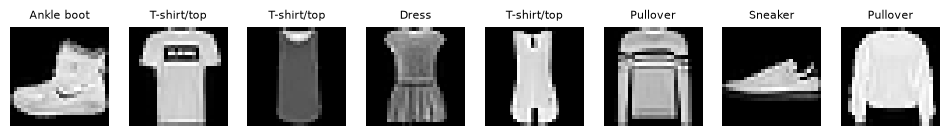

In [7]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

x_train, y_train = x_train_full[:50_000], y_train_full[:50_000]
x_val, y_val = x_train_full[50_000:], y_train_full[50_000:]
print("train", x_train.shape, "| val", x_val.shape, "| test", x_test.shape, "| dtype", x_train.dtype)
print("validation images per class:", np.bincount(y_val).tolist())

x_train_flat = x_train.reshape(-1, 784).astype("float32") / 255.0
x_val_flat = x_val.reshape(-1, 784).astype("float32") / 255.0

fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for ax, img, label in zip(axes, x_train[:8], y_train[:8]):
    ax.imshow(img, cmap="gray")
    ax.set_title(class_names[label], fontsize=8)
    ax.axis("off")
plt.show()

In [8]:
keras.utils.set_random_seed(0)
mlp = make_sequential()
mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),   # labels are integers; outputs are logits
    metrics=["accuracy"],
)
start = time.perf_counter()
mlp_history = mlp.fit(x_train_flat, y_train, validation_data=(x_val_flat, y_val), epochs=3, batch_size=128, verbose=2)
keras_mlp_seconds = time.perf_counter() - start

val_loss, val_acc = mlp.evaluate(x_val_flat, y_val, verbose=0)
print(f"\nvalidation → loss {val_loss:.3f} | accuracy {val_acc:.3f} | trained in {keras_mlp_seconds:.1f} s")
print("history keys:", list(mlp_history.history.keys()))

Epoch 1/3


391/391 - 2s - 6ms/step - accuracy: 0.8033 - loss: 0.5655 - val_accuracy: 0.8295 - val_loss: 0.4868


Epoch 2/3


391/391 - 2s - 6ms/step - accuracy: 0.8556 - loss: 0.4129 - val_accuracy: 0.8467 - val_loss: 0.4154


Epoch 3/3


391/391 - 2s - 6ms/step - accuracy: 0.8667 - loss: 0.3733 - val_accuracy: 0.8650 - val_loss: 0.3776



validation → loss 0.378 | accuracy 0.865 | trained in 6.7 s
history keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


### ✍️ Your Turn

`predict` returns **logits** of shape `(10000, 10)`. Compute the validation **accuracy** yourself from `val_logits` and `y_val`, and confirm it matches `evaluate`.

In [9]:
val_logits = mlp.predict(x_val_flat, verbose=0)
my_val_acc = None  # TODO: your code here
check("my_val_acc", my_val_acc, val_acc, hint="np.mean(val_logits.argmax(axis=1) == y_val)", atol=1e-4)

⏳ my_val_acc: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
val_logits = mlp.predict(x_val_flat, verbose=0)
my_val_acc = np.mean(val_logits.argmax(axis=1) == y_val)
check("my_val_acc", my_val_acc, val_acc, atol=1e-4)
```
The largest logit is also the largest probability, so you don't need a softmax to pick the class.
</details>

> 💡 **Interview angle:** "What does `validation_split=0.2` do?" — it takes the **last** 20% of the arrays **before shuffling**. If your data is sorted (by time or by class), that validation set is biased — split explicitly and pass `validation_data` instead.

## 4. Callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau 🟡

A **callback** is code that `fit` runs at set moments (start/end of each epoch or batch).

| Callback | What it does |
|---|---|
| `EarlyStopping(monitor="val_loss", patience=p, restore_best_weights=True)` | stop when validation stops improving for `p` epochs, and roll back to the best weights |
| `ModelCheckpoint("best.keras", save_best_only=True)` | save the best model to disk as training runs |
| `ReduceLROnPlateau(factor=0.5, patience=q)` | halve the learning rate when validation plateaus |
| subclass `keras.callbacks.Callback` | your own logic, e.g. timing or logging |

To see them fire quickly, we deliberately **overfit**: a wide network trained on only 2,000 images.

In [10]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.seconds = []

    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.seconds.append(time.perf_counter() - self._start)


keras.utils.set_random_seed(1)
overfit_model = keras.Sequential([keras.Input(shape=(784,)), layers.Dense(512, activation="relu"), layers.Dense(10)])
overfit_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                      loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])

timer = EpochTimer()
checkpoint_path = OUTPUT_DIR / "overfit_best.keras"
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(str(checkpoint_path), monitor="val_loss", save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, verbose=1),
    timer,
]
cb_history = overfit_model.fit(x_train_flat[:2000], y_train[:2000], validation_data=(x_val_flat, y_val),
                               epochs=40, batch_size=64, verbose=0, callbacks=callbacks)

val_losses = cb_history.history["val_loss"]
best_epoch = int(np.argmin(val_losses))
print(f"\nran {len(val_losses)} of 40 epochs (avg {np.mean(timer.seconds):.2f} s/epoch)")
print(f"best val_loss {val_losses[best_epoch]:.4f} at epoch {best_epoch + 1}")
print("learning rate per epoch:", [f"{lr:.1e}" for lr in cb_history.history["learning_rate"]])

restored_loss = overfit_model.evaluate(x_val_flat, y_val, verbose=0)[0]
checkpoint_loss = keras.models.load_model(checkpoint_path).evaluate(x_val_flat, y_val, verbose=0)[0]
print(f"model after fit (restored best weights): val_loss {restored_loss:.4f}")
print(f"model loaded from checkpoint           : val_loss {checkpoint_loss:.4f}")
assert np.isclose(restored_loss, val_losses[best_epoch], atol=1e-3) and np.isclose(checkpoint_loss, val_losses[best_epoch], atol=1e-3)


Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



Epoch 10: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.



Epoch 14: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


...


Epoch 16: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 13.



ran 16 of 40 epochs (avg 0.64 s/epoch)
best val_loss 0.4924 at epoch 13
learning rate per epoch: ['1.0e-03', '1.0e-03', '1.0e-03', '1.0e-03', '1.0e-03', '5.0e-04', '5.0e-04', '2.5e-04', '2.5e-04', '1.3e-04', '6.3e-05', '6.3e-05', '6.3e-05', '6.3e-05', '3.1e-05', '1.6e-05']


model after fit (restored best weights): val_loss 0.4924
model loaded from checkpoint           : val_loss 0.4924


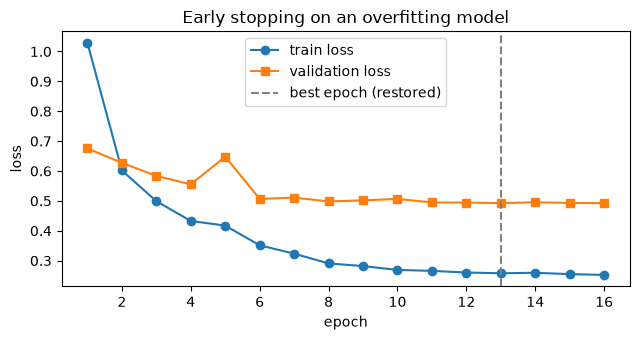

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(range(1, len(val_losses) + 1), cb_history.history["loss"], "o-", label="train loss")
ax.plot(range(1, len(val_losses) + 1), val_losses, "s-", label="validation loss")
ax.axvline(best_epoch + 1, color="gray", linestyle="--", label="best epoch (restored)")
ax.set(xlabel="epoch", ylabel="loss", title="Early stopping on an overfitting model")
ax.legend()
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "How does early stopping prevent overfitting — and what's the classic mistake?" — it monitors a **validation** metric and keeps the best weights (`restore_best_weights=True`; without it you keep the *last* epoch's weights). Monitoring the **test** set is leakage: your final test score becomes optimistic.

## 5. Preprocessing Layers 🟡

**Preprocessing layers** turn data preparation into layers, so it can live **inside the model**. Then the saved model accepts raw inputs, and training and serving can't drift apart (**training/serving skew**).

- `Normalization` — learns mean/variance with `.adapt(data)` (**training data only**)
- `Rescaling(1/255)` — fixed scaling
- Augmentation (`RandomFlip`, `RandomTranslation`, `RandomRotation`, …) — random changes that are **only active when `training=True`** (inside `fit`), and do nothing in `evaluate`/`predict`

learned mean 0.2855 vs NumPy 0.2855
learned var  0.1245 vs NumPy 0.1245


validation after normalization → mean 0.009, std 1.004

two calls with training=True differ : True
training=False leaves the image as-is: True


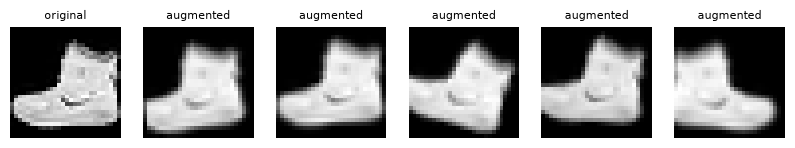

In [12]:
normalizer = layers.Normalization(axis=None)                     # one mean/variance for all pixels
normalizer.adapt(x_train_flat)                                    # learn statistics from TRAIN only
print(f"learned mean {to_np(normalizer.mean).item():.4f} vs NumPy {x_train_flat.mean():.4f}")
print(f"learned var  {to_np(normalizer.variance).item():.4f} vs NumPy {x_train_flat.var():.4f}")
val_normalized = to_np(normalizer(x_val_flat))
print(f"validation after normalization → mean {val_normalized.mean():.3f}, std {val_normalized.std():.3f}")

augment = keras.Sequential([
    layers.RandomFlip("horizontal", seed=1),
    layers.RandomTranslation(0.1, 0.1, fill_mode="constant", seed=2),
    layers.RandomRotation(0.05, fill_mode="constant", seed=3),
], name="augment")

image = x_train[:1, ..., None].astype("float32")                  # (1, 28, 28, 1)
aug_a, aug_b = to_np(augment(image, training=True)), to_np(augment(image, training=True))
print("\ntwo calls with training=True differ :", not np.allclose(aug_a, aug_b))
print("training=False leaves the image as-is:", np.allclose(to_np(augment(image, training=False)), image))

fig, axes = plt.subplots(1, 6, figsize=(10, 1.9))
axes[0].imshow(image[0, ..., 0], cmap="gray")
axes[0].set_title("original", fontsize=8)
for ax in axes[1:]:
    ax.imshow(to_np(augment(image, training=True))[0, ..., 0], cmap="gray")
    ax.set_title("augmented", fontsize=8)
for ax in axes:
    ax.axis("off")
plt.show()

Some preprocessing layers are implemented with TensorFlow's string ops. Here's an honest check:

In [13]:
try:
    layers.TextVectorization(max_tokens=1000)
    print("TextVectorization is available (TensorFlow is installed).")
except ImportError as err:
    print(f"⏭️ TextVectorization is unavailable on this setup: {err}")
    print("   → with the torch backend, tokenize text beforehand (e.g. a Hugging Face tokenizer) and feed integer ids.")

⏭️ TextVectorization is unavailable on this setup: Layer TextVectorization requires TensorFlow. Install it via `pip install tensorflow`.
   → with the torch backend, tokenize text beforehand (e.g. a Hugging Face tokenizer) and feed integer ids.


### ✍️ Your Turn

A feature has training values `[1, 2, 3, 4]`. Create a `layers.Normalization()` layer, **adapt it on the training values only**, and use it to transform a new value `5.0`. Store the transformed value in `normalized_five` (shape `(1, 1)`).

In [14]:
feature_train = np.array([[1.0], [2.0], [3.0], [4.0]], dtype="float32")
new_value = np.array([[5.0]], dtype="float32")
normalized_five = None  # TODO: your code here
check("normalized_five", normalized_five, [[2.2360680]],
      hint="norm = layers.Normalization(); norm.adapt(feature_train); norm(new_value) — mean 2.5, variance 1.25.")

⏳ normalized_five: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
feature_train = np.array([[1.0], [2.0], [3.0], [4.0]], dtype="float32")
new_value = np.array([[5.0]], dtype="float32")
feature_norm = layers.Normalization()
feature_norm.adapt(feature_train)
normalized_five = feature_norm(new_value)
check("normalized_five", normalized_five, [[2.2360680]])
```
`(5 − 2.5) / √1.25 ≈ 2.236`. The statistics come from training data only, so new data can land outside the training range — that's expected, not a bug.
</details>

> 💡 **Interview angle:** "Where should normalization and augmentation live?" — inside the model (or one shared function) so serving uses the exact same transforms; fit normalization statistics on the **training split only**; augmentation must be re-sampled every batch, never computed once and cached.

## 6. Backend-Agnostic Custom Layers and Losses 🟡

Rules for custom Keras code that works on **every** backend and can be saved:

1. Use **`keras.ops`** (not `torch.*`, `tf.*`, or `jax.*`) for math.
2. Create weights in **`build(input_shape)`** with `self.add_weight(...)`, so shapes can come from the input.
3. Put the computation in **`call()`**.
4. Return constructor arguments from **`get_config()`** and decorate the class with **`@keras.saving.register_keras_serializable()`** so `.keras` files can rebuild it.

Example: a leaky ReLU whose negative slope is **learned** per feature — the same idea as Keras's built-in `PReLU`.

In [15]:
@keras.saving.register_keras_serializable(package="course")
class LearnableLeakyReLU(layers.Layer):
    """f(x) = x for x > 0, alpha · x otherwise — with one trainable alpha per feature."""

    def __init__(self, alpha_init=0.25, **kwargs):
        super().__init__(**kwargs)
        self.alpha_init = alpha_init

    def build(self, input_shape):
        self.alpha = self.add_weight(shape=(input_shape[-1],), name="alpha",
                                     initializer=keras.initializers.Constant(self.alpha_init))

    def call(self, inputs):
        return ops.where(inputs > 0, inputs, self.alpha * inputs)

    def get_config(self):
        return {**super().get_config(), "alpha_init": self.alpha_init}


x_act = np.random.default_rng(0).normal(size=(4, 6)).astype("float32")
ours_act = LearnableLeakyReLU(alpha_init=0.25)
builtin_prelu = layers.PReLU(alpha_initializer=keras.initializers.Constant(0.25))
assert np.allclose(to_np(ours_act(x_act)), to_np(builtin_prelu(x_act)), atol=1e-6)
print("LearnableLeakyReLU == keras.layers.PReLU ✅ | trainable weights:", [tuple(w.shape) for w in ours_act.trainable_weights])
print("config:", ours_act.get_config())

LearnableLeakyReLU == keras.layers.PReLU ✅ | trainable weights: [(6,)]
config: {'name': 'learnable_leaky_re_lu', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'alpha_init': 0.25}


A custom **loss** can be a plain function of `(y_true, y_pred)` returning one value per sample. Here is Huber loss (quadratic for small errors, linear for large ones — robust to outliers):

In [16]:
def huber_loss(y_true, y_pred, delta=1.0):
    error = ops.abs(y_true - y_pred)
    quadratic = 0.5 * ops.square(error)
    linear = delta * error - 0.5 * delta**2
    return ops.mean(ops.where(error <= delta, quadratic, linear), axis=-1)     # one value per sample


y_true_reg = np.array([[0.0], [2.0], [5.0], [1.0]], dtype="float32")
y_pred_reg = np.array([[0.5], [1.0], [1.0], [1.2]], dtype="float32")
ours_huber = float(to_np(ops.mean(huber_loss(y_true_reg, y_pred_reg))))
builtin_huber = float(to_np(keras.losses.Huber(delta=1.0)(y_true_reg, y_pred_reg)))
print(f"our Huber {ours_huber:.5f} | keras.losses.Huber {builtin_huber:.5f}")
assert np.isclose(ours_huber, builtin_huber)

our Huber 1.03625 | keras.losses.Huber 1.03625


### ✍️ Your Turn

Implement the **swish / SiLU** activation `x · sigmoid(x)` with `keras.ops` and compare with `keras.activations.silu`.

In [17]:
x_swish = ops.convert_to_tensor([-2.0, -0.5, 0.0, 1.0, 3.0])
my_swish = None  # TODO: your code here
check("my_swish", my_swish, keras.activations.silu(x_swish), hint="x_swish * ops.sigmoid(x_swish)")

⏳ my_swish: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_swish = ops.convert_to_tensor([-2.0, -0.5, 0.0, 1.0, 3.0])
my_swish = x_swish * ops.sigmoid(x_swish)
check("my_swish", my_swish, keras.activations.silu(x_swish))
```
</details>

> 💡 **Interview angle:** "How do you write a custom layer that saves and reloads?" — weights in `build` via `add_weight`, math in `call` with `keras.ops`, constructor args in `get_config`, and `@register_keras_serializable` (or pass `custom_objects` to `load_model`).

## 7. Saving and Loading with .keras 🟢

| Format | Contains | Use for |
|---|---|---|
| `model.save("model.keras")` | architecture + weights + optimizer state, in one zip file | resuming training, sharing a Keras model |
| `model.save_weights("model.weights.h5")` | weights only | when you rebuild the architecture in code |
| `model.export(path, format=...)` | an inference artifact: `"tf_saved_model"`, `"onnx"`, `"openvino"`, `"litert"`, `"torch"` | serving (most formats need extra packages) |

In [18]:
keras.utils.set_random_seed(2)
model_to_save = keras.Sequential([keras.Input(shape=(6,)), layers.Dense(8), LearnableLeakyReLU(), layers.Dense(1)])
model_to_save.compile(optimizer="adam", loss="mse")
x_small = np.random.default_rng(1).normal(size=(64, 6)).astype("float32")
y_small = x_small.sum(axis=1, keepdims=True)
model_to_save.fit(x_small, y_small, epochs=5, verbose=0)

keras_path = OUTPUT_DIR / "custom_model.keras"
model_to_save.save(keras_path)
reloaded = keras.models.load_model(keras_path)                   # finds LearnableLeakyReLU via the registry
assert np.allclose(model_to_save.predict(x_small, verbose=0), reloaded.predict(x_small, verbose=0), atol=1e-6)
print("reloaded .keras model gives identical predictions ✅")
print("inside the .keras zip:", zipfile.ZipFile(keras_path).namelist())

weights_path = OUTPUT_DIR / "custom_model.weights.h5"
model_to_save.save_weights(weights_path)
fresh = keras.Sequential([keras.Input(shape=(6,)), layers.Dense(8), LearnableLeakyReLU(), layers.Dense(1)])
fresh.load_weights(weights_path)
assert np.allclose(model_to_save.predict(x_small, verbose=0), fresh.predict(x_small, verbose=0), atol=1e-6)
print("weights-only round trip ✅")

reloaded .keras model gives identical predictions ✅
inside the .keras zip: ['metadata.json', 'config.json', 'model.weights.h5']
weights-only round trip ✅


In [19]:
try:
    export_path = OUTPUT_DIR / "custom_model.pt2"
    model_to_save.export(str(export_path), format="torch", verbose=False)    # a torch.export ExportedProgram
    print(f"exported for PyTorch serving: {export_path.name} ({export_path.stat().st_size / 1024:.0f} KB)")
except Exception as err:  # noqa: BLE001 — export support varies by backend and installed packages
    print(f"⏭️ Skipped model.export(format='torch'): {type(err).__name__}: {err}")

exported for PyTorch serving: custom_model.pt2 (60 KB)


> 💡 **Interview angle:** "`.keras` vs weights vs export?" — `.keras` is the full, backend-portable Keras model (config + weights + optimizer) for continuing work; weights files need the code; `export()` produces a runtime artifact (SavedModel for TF Serving, LiteRT for mobile, ONNX/OpenVINO/torch for other servers) that no longer needs your Python classes.

## 8. The Same Model in Keras vs PyTorch 🟡

| Keras | PyTorch |
|---|---|
| `keras.Model` / `layers.Layer` with `call()` | `nn.Module` with `forward()` |
| `layers.Dense(128, activation="relu")` | `nn.Linear(in, 128)` + `nn.ReLU()` (input size required) |
| `compile(optimizer, loss, metrics)` + `fit(...)` | write the loop: `loss.backward()`, `optimizer.step()`, `zero_grad()` |
| `validation_data=`, callbacks | your own evaluation code, schedulers, `if` statements |
| `model.save("m.keras")` | `torch.save(model.state_dict(), "m.pt")` |

We train the exact PyTorch equivalent of the Keras MLP from Section 3 — same architecture, optimizer, batch size, and 3 epochs.

In [20]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

torch_device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
torch.manual_seed(0)
torch_mlp = torch.nn.Sequential(torch.nn.Linear(784, 128), torch.nn.ReLU(), torch.nn.Linear(128, 10)).to(torch_device)
torch_opt = torch.optim.Adam(torch_mlp.parameters(), lr=1e-3)
loader = DataLoader(TensorDataset(torch.from_numpy(x_train_flat), torch.from_numpy(y_train.astype(np.int64))),
                    batch_size=128, shuffle=True)

start = time.perf_counter()
for epoch in range(3):
    torch_mlp.train()
    for xb, yb in loader:
        xb, yb = xb.to(torch_device), yb.to(torch_device)
        loss = F.cross_entropy(torch_mlp(xb), yb)
        torch_opt.zero_grad()
        loss.backward()
        torch_opt.step()
torch_seconds = time.perf_counter() - start

torch_mlp.eval()
with torch.no_grad():
    torch_val_acc = (torch_mlp(torch.from_numpy(x_val_flat).to(torch_device)).argmax(1).cpu().numpy() == y_val).mean()

torch_params = sum(p.numel() for p in torch_mlp.parameters())
print(f"{'':8s} {'params':>8s} {'val acc':>8s} {'train time':>11s}")
print(f"{'Keras':8s} {mlp.count_params():8,d} {val_acc:8.3f} {keras_mlp_seconds:10.1f}s")
print(f"{'PyTorch':8s} {torch_params:8,d} {torch_val_acc:8.3f} {torch_seconds:10.1f}s")
assert mlp.count_params() == torch_params

           params  val acc  train time
Keras     101,770    0.865        6.7s
PyTorch   101,770    0.860        2.8s


Same parameter count and similar accuracy (small differences come from random initialization and shuffling). Keras saves you the loop; PyTorch gives you full control over every step. Because a Keras model on this backend *is* an `nn.Module`, you can even mix the two.

> 💡 **Interview angle:** "Why do most LLM teams use PyTorch instead of Keras?" — the open-source ecosystem (Hugging Face, vLLM, DeepSpeed/FSDP), custom training loops for RLHF/DPO and distributed training, and debugging with plain Python. Keras is strong for fast, standard training and Google-ecosystem deployment (TF Serving, LiteRT, TPUs via JAX).

## 🔧 Build It From Scratch

### 1) A `Dense` layer with `keras.ops`

`Dense` computes `activation(x · W + b)`. We write it ourselves, copy the built-in layer's weights into ours, and assert identical outputs.

In [21]:
@keras.saving.register_keras_serializable(package="course")
class MyDense(layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation_name = activation
        self.activation = keras.activations.get(activation)       # None → linear

    def build(self, input_shape):
        self.kernel = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform", name="kernel")
        self.bias = self.add_weight(shape=(self.units,), initializer="zeros", name="bias")

    def call(self, inputs):
        return self.activation(ops.matmul(inputs, self.kernel) + self.bias)

    def get_config(self):
        return {**super().get_config(), "units": self.units, "activation": self.activation_name}


x_dense = np.random.default_rng(0).normal(size=(3, 7)).astype("float32")
builtin_dense = layers.Dense(5, activation="relu")
my_dense = MyDense(5, activation="relu")
builtin_dense(x_dense), my_dense(x_dense)                              # build both
my_dense.set_weights(builtin_dense.get_weights())                      # same kernel (7, 5) and bias (5,)
assert np.allclose(to_np(my_dense(x_dense)), to_np(builtin_dense(x_dense)), atol=1e-6)
assert my_dense.count_params() == builtin_dense.count_params() == 7 * 5 + 5
print("MyDense == keras.layers.Dense ✅ | parameters:", my_dense.count_params())

MyDense == keras.layers.Dense ✅ | parameters: 40


### 2) A correct binary focal loss

**Focal loss** (Lin et al., 2017) down-weights **easy** examples so training focuses on hard ones — useful for heavy class imbalance (fraud, rare diseases, object detection). With `p_t` = the predicted probability of the **true** class:

$$\text{FL} = -\,\alpha_t\,(1 - p_t)^{\gamma}\,\log(p_t), \qquad \alpha_t = \begin{cases}\alpha & y = 1\\ 1-\alpha & y = 0\end{cases}$$

- `γ` (gamma) controls down-weighting: `γ = 0` removes it.
- `α` (alpha) weights the **positive** class by `α` and the **negative** class by `1 − α`. With `alpha=None`, no class weighting.
- So **`γ = 0` and `alpha=None` gives exactly binary cross-entropy** — but `γ = 0` with `α = 0.25` does *not* (the old version of this notebook got both of these wrong).
- **Shapes:** inside `fit`, a subclassed `Loss` receives labels of shape `(N,)` and `Dense(1)` predictions of shape `(N, 1)` exactly as they are. Without reshaping, `y_true * p` silently broadcasts to an `(N, N)` matrix and the model can't learn — so `call()` aligns the shapes first.

In [22]:
@keras.saving.register_keras_serializable(package="course")
class BinaryFocalLoss(keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=None, name="binary_focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma, self.alpha = gamma, alpha

    def call(self, y_true, y_pred):
        # A subclassed Loss receives shapes as-is: labels (N,) vs a Dense(1) output (N, 1) would broadcast to (N, N)
        y_true = ops.reshape(ops.cast(y_true, y_pred.dtype), ops.shape(y_pred))
        eps = keras.config.epsilon()
        p = ops.clip(y_pred, eps, 1.0 - eps)                           # avoid log(0)
        p_t = y_true * p + (1.0 - y_true) * (1.0 - p)                   # probability of the TRUE class
        loss = -ops.power(1.0 - p_t, self.gamma) * ops.log(p_t)
        if self.alpha is not None:
            alpha_t = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)
            loss = alpha_t * loss
        return ops.mean(loss, axis=-1)

    def get_config(self):
        return {**super().get_config(), "gamma": self.gamma, "alpha": self.alpha}


rng_fl = np.random.default_rng(0)
y_true_fl = rng_fl.integers(0, 2, size=200).astype("float32")                  # 1-D labels
y_prob_fl = rng_fl.uniform(0.02, 0.98, size=200).astype("float32")              # predicted P(y = 1)


def loss_value(loss_fn, yt=y_true_fl, yp=y_prob_fl):
    return float(to_np(loss_fn(yt, yp)))


# a) gamma = 0, alpha = None  → exactly binary cross-entropy
assert np.isclose(loss_value(BinaryFocalLoss(gamma=0.0)), loss_value(keras.losses.BinaryCrossentropy()), atol=1e-5)
print("✅ gamma=0, alpha=None equals BinaryCrossentropy")

# b) gamma = 2 without / with class balancing → Keras built-in BinaryFocalCrossentropy
assert np.isclose(loss_value(BinaryFocalLoss(gamma=2.0)), loss_value(keras.losses.BinaryFocalCrossentropy(gamma=2.0)), atol=1e-5)
assert np.isclose(loss_value(BinaryFocalLoss(gamma=2.0, alpha=0.25)),
                  loss_value(keras.losses.BinaryFocalCrossentropy(apply_class_balancing=True, alpha=0.25, gamma=2.0)), atol=1e-5)
print("✅ matches keras.losses.BinaryFocalCrossentropy (with and without class balancing)")

# c) alpha weights positives by alpha and negatives by 1 - alpha
pos, neg = y_true_fl == 1, y_true_fl == 0
for mask_cls, weight, label in [(pos, 0.25, "positives"), (neg, 0.75, "negatives")]:
    weighted = loss_value(BinaryFocalLoss(gamma=2.0, alpha=0.25), y_true_fl[mask_cls], y_prob_fl[mask_cls])
    unweighted = loss_value(BinaryFocalLoss(gamma=2.0), y_true_fl[mask_cls], y_prob_fl[mask_cls])
    assert np.isclose(weighted, weight * unweighted, atol=1e-6)
    print(f"✅ {label} are weighted by {weight}")

# d) labels (N,) with predictions (N, 1) — the shapes fit() passes — give the same value as matching shapes
assert np.isclose(loss_value(BinaryFocalLoss(gamma=2.0), y_true_fl, y_prob_fl[:, None]), loss_value(BinaryFocalLoss(gamma=2.0)), atol=1e-6)
print("✅ (N,) labels with (N, 1) predictions handled correctly")

# e) the old claim "gamma=0 with alpha=0.25 equals BCE" is false
print(f"gamma=0, alpha=0.25 → {loss_value(BinaryFocalLoss(gamma=0.0, alpha=0.25)):.4f} vs BCE {loss_value(keras.losses.BinaryCrossentropy()):.4f} (not equal)")

# f) focal loss shrinks easy examples far more than hard ones
easy_hard = np.array([1.0, 1.0], dtype="float32"), np.array([0.95, 0.30], dtype="float32")
focal_each = [loss_value(BinaryFocalLoss(gamma=2.0), easy_hard[0][i:i + 1], easy_hard[1][i:i + 1]) for i in range(2)]
bce_each = [loss_value(keras.losses.BinaryCrossentropy(), easy_hard[0][i:i + 1], easy_hard[1][i:i + 1]) for i in range(2)]
print(f"easy example (p_t=0.95): focal/BCE = {focal_each[0] / bce_each[0]:.4f} | hard example (p_t=0.30): focal/BCE = {focal_each[1] / bce_each[1]:.2f}")

✅ gamma=0, alpha=None equals BinaryCrossentropy
✅ matches keras.losses.BinaryFocalCrossentropy (with and without class balancing)
✅ positives are weighted by 0.25
✅ negatives are weighted by 0.75
✅ (N,) labels with (N, 1) predictions handled correctly
gamma=0, alpha=0.25 → 0.4517 vs BCE 0.9166 (not equal)
easy example (p_t=0.95): focal/BCE = 0.0025 | hard example (p_t=0.30): focal/BCE = 0.49


### 3) Use both on real data: IMDB movie-review sentiment

The [IMDB dataset](https://ai.stanford.edu/~amaas/data/sentiment/) in `keras.datasets` has 50,000 reviews already converted to word ids (~17 MB). We turn each review into a **multi-hot** vector over the 5,000 most frequent words and train `MyDense` layers with `BinaryFocalLoss`, comparing with ordinary BCE on a validation split (we don't use the IMDB test set here).

In [23]:
(imdb_x, imdb_y), _ = keras.datasets.imdb.load_data(num_words=5_000)
N_WORDS = 5_000


def multi_hot(sequences, dim=N_WORDS):
    out = np.zeros((len(sequences), dim), dtype="uint8")          # uint8 keeps memory small (20k × 5k = 100 MB)
    for i, seq in enumerate(sequences):
        out[i, seq] = 1
    return out


imdb_train_x, imdb_train_y = multi_hot(imdb_x[:20_000]), imdb_y[:20_000].astype("float32")
imdb_val_x, imdb_val_y = multi_hot(imdb_x[20_000:]), imdb_y[20_000:].astype("float32")
print("train", imdb_train_x.shape, "| val", imdb_val_x.shape, "| positive rate", imdb_train_y.mean().round(3))

imdb_results = {}
for loss_name, loss_obj in [("BCE", keras.losses.BinaryCrossentropy()), ("focal γ=2", BinaryFocalLoss(gamma=2.0))]:
    keras.utils.set_random_seed(3)
    sentiment = keras.Sequential([keras.Input(shape=(N_WORDS,)), MyDense(16, activation="relu"), MyDense(1, activation="sigmoid")])
    sentiment.compile(optimizer=keras.optimizers.Adam(1e-3), loss=loss_obj, metrics=["accuracy"])
    hist = sentiment.fit(imdb_train_x.astype("float32"), imdb_train_y, validation_data=(imdb_val_x.astype("float32"), imdb_val_y),
                         epochs=4, batch_size=512, verbose=0)
    best = int(np.argmax(hist.history["val_accuracy"]))
    imdb_results[loss_name] = hist.history["val_accuracy"][best]
    print(f"{loss_name:10s} best val accuracy {imdb_results[loss_name]:.3f} (epoch {best + 1})")

print("→ on this balanced dataset both losses reach similar accuracy; focal loss pays off mainly with heavy class imbalance."
      if abs(imdb_results["BCE"] - imdb_results["focal γ=2"]) < 0.02 else
      f"→ accuracy gap of {abs(imdb_results['BCE'] - imdb_results['focal γ=2']):.3f} between the losses on this run.")

train (20000, 5000) | val (5000, 5000) | positive rate 0.502


BCE        best val accuracy 0.887 (epoch 4)


focal γ=2  best val accuracy 0.884 (epoch 3)
→ on this balanced dataset both losses reach similar accuracy; focal loss pays off mainly with heavy class imbalance.


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Saving without the `.keras` extension

In [24]:
try:
    model_to_save.save(OUTPUT_DIR / "my_model")                        # ❌ Keras 3 needs an explicit format
except ValueError as err:
    print("❌", str(err).split(".")[0] + ".")

model_to_save.save(OUTPUT_DIR / "my_model.keras")                     # ✅
print("✅ saved", OUTPUT_DIR / "my_model.keras")

❌ Invalid filepath extension for saving.
✅ saved _outputs/my_model.keras


### ❌ Pitfall 2 — "Random" augmentation computed once

If augmented images are computed **once** and reused (for example by caching a data pipeline *after* the augmentation step), every epoch sees the same "random" images and augmentation stops helping. Keep augmentation inside the model so it is re-sampled for every batch.

In [25]:
batch_imgs = x_train[:16, ..., None].astype("float32")
shift = layers.RandomTranslation(0.15, 0.15, fill_mode="constant", seed=7)

frozen = to_np(shift(batch_imgs, training=True))                     # ❌ computed once, reused for every epoch
epoch_1_bad, epoch_2_bad = frozen, frozen
print("❌ epochs 1 and 2 see different augmentations:", not np.array_equal(epoch_1_bad, epoch_2_bad))

epoch_1, epoch_2 = to_np(shift(batch_imgs, training=True)), to_np(shift(batch_imgs, training=True))   # ✅ fresh each batch
print("✅ epochs 1 and 2 see different augmentations:", not np.array_equal(epoch_1, epoch_2))

❌ epochs 1 and 2 see different augmentations: False
✅ epochs 1 and 2 see different augmentations: True


### ❌ Pitfall 3 — Treating `optimizer.learning_rate` as a function

In [26]:
opt_demo = keras.optimizers.Adam(learning_rate=1e-3)
try:
    opt_demo.learning_rate(0)                                          # ❌
except TypeError as err:
    print("❌ TypeError:", err)

print("✅ read :", float(opt_demo.learning_rate))                       # it's a Variable
opt_demo.learning_rate.assign(1e-4)
print("✅ write:", float(opt_demo.learning_rate))

❌ TypeError: 'Variable' object is not callable
✅ read : 0.0010000000474974513
✅ write: 9.999999747378752e-05


### ❌ Pitfall 4 — Using removed Keras 2 arguments like `Embedding(input_length=...)`

In [27]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    layers.Embedding(input_dim=1000, output_dim=16, input_length=100)   # ❌ Keras 2 argument
print("❌ warning:", [str(w.message) for w in caught])

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    layers.Embedding(input_dim=1000, output_dim=16)                    # ✅ sequence length comes from the input
print("✅ warnings:", [str(w.message) for w in caught])

❌ warning: ['Argument `input_length` is deprecated. Just remove it.']
✅ warnings: []


### ❌ Pitfall 5 — `from_logits` mismatch

If the last layer already applies **softmax** but the loss says `from_logits=True`, Keras applies softmax **twice**. Nothing crashes — the model just learns worse.

In [28]:
def train_quick(final_activation, from_logits, n=10_000, epochs=3):
    keras.utils.set_random_seed(5)
    model_q = keras.Sequential([keras.Input(shape=(784,)), layers.Dense(128, activation="relu"),
                                layers.Dense(10, activation=final_activation)])
    model_q.compile(optimizer=keras.optimizers.Adam(1e-3),
                    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=from_logits), metrics=["accuracy"])
    model_q.fit(x_train_flat[:n], y_train[:n], epochs=epochs, batch_size=128, verbose=0)
    return model_q.evaluate(x_val_flat, y_val, verbose=0)


bad_loss, bad_acc = train_quick("softmax", from_logits=True)             # ❌ softmax output + from_logits=True
good_loss, good_acc = train_quick(None, from_logits=True)                # ✅ logits output + from_logits=True
print(f"❌ softmax + from_logits=True : val accuracy {bad_acc:.3f} | reported loss {bad_loss:.3f} (a meaningless number)")
print(f"✅ logits  + from_logits=True : val accuracy {good_acc:.3f} | loss {good_loss:.3f}")

❌ softmax + from_logits=True : val accuracy 0.751 | reported loss 1.723 (a meaningless number)
✅ logits  + from_logits=True : val accuracy 0.829 | loss 0.491


### ❌ Pitfall 6 — Trusting a built-in loss without a unit test

Loss functions interact with tensor **shapes**. Compare the built-in `BinaryFocalCrossentropy` on column-shaped `(N, 1)` targets — the shape a `Dense(1)` model produces — with a value computed by hand in NumPy. The result depends on the backend and device, so the cell prints whatever it finds on your machine.

In [29]:
y_true_col = np.array([[1.0], [0.0], [1.0], [0.0]], dtype="float32")
y_prob_col = np.array([[0.9], [0.2], [0.3], [0.6]], dtype="float32")
p_t_np = y_true_col * y_prob_col + (1 - y_true_col) * (1 - y_prob_col)
by_hand = float(np.mean((1 - p_t_np) ** 2 * -np.log(p_t_np)))

builtin_col = loss_value(keras.losses.BinaryFocalCrossentropy(gamma=2.0), y_true_col, y_prob_col)
builtin_flat = loss_value(keras.losses.BinaryFocalCrossentropy(gamma=2.0), y_true_col.ravel(), y_prob_col.ravel())
ours_col = loss_value(BinaryFocalLoss(gamma=2.0), y_true_col, y_prob_col)
print(f"by hand (NumPy)               : {by_hand:.4f}")
print(f"our BinaryFocalLoss, (N, 1)   : {ours_col:.4f}")
print(f"built-in, 1-D targets (N,)    : {builtin_flat:.4f}")
print(f"built-in, column targets (N,1): {builtin_col:.4f}")
if not np.isclose(builtin_col, by_hand, atol=1e-4):
    print(f"❌ On this setup (keras {keras.__version__}, {keras.config.backend()} backend, MPS available: "
          f"{torch.backends.mps.is_available()}) the built-in gives a different value for (N, 1) targets — "
          "its internal BCE is squeezed to (N,) and then broadcast against (N, 1) into an (N, N) matrix.")
    print("✅ Unit-test losses against a hand-computed value for the exact shapes your model produces.")
else:
    print("✅ The built-in matches the hand-computed value on this setup — keep a test like this anyway.")
assert np.isclose(ours_col, by_hand, atol=1e-5)

by hand (NumPy)               : 0.2324
our BinaryFocalLoss, (N, 1)   : 0.2324
built-in, 1-D targets (N,)    : 0.2324
built-in, column targets (N,1): 0.1377
❌ On this setup (keras 3.15.1, torch backend, MPS available: True) the built-in gives a different value for (N, 1) targets — its internal BCE is squeezed to (N,) and then broadcast against (N, 1) into an (N, N) matrix.
✅ Unit-test losses against a hand-computed value for the exact shapes your model produces.


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Count Dense parameters
How many parameters does `layers.Dense(64)` have when its input has 784 features? Store an integer.

In [30]:
dense_params = None  # TODO
check("dense_params", dense_params, 50_240, hint="weights (inputs × units) + one bias per unit.")

⏳ dense_params: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dense_params = 784 * 64 + 64
check("dense_params", dense_params, 50_240)
```
Verify: `keras.Sequential([keras.Input((784,)), layers.Dense(64)]).count_params()`.
</details>

### 🟢 Exercise 2 — A Sequential classifier
Build `clf`: input of 20 features → `Dense(16, relu)` → `Dense(3, softmax)`.

In [31]:
clf = None  # TODO
check("clf", None if clf is None else (clf.count_params(), clf.output_shape[-1]), (387, 3),
      hint="keras.Sequential([keras.Input(shape=(20,)), layers.Dense(16, activation='relu'), layers.Dense(3, activation='softmax')])")

⏳ clf: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
clf = keras.Sequential([
    keras.Input(shape=(20,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(3, activation="softmax"),
])
check("clf", (clf.count_params(), clf.output_shape[-1]), (387, 3))
```
20·16 + 16 = 336 and 16·3 + 3 = 51 → 387.
</details>

### 🟢 Exercise 3 — Configure early stopping
Create `early_stop` that watches **validation accuracy**, waits **3** epochs without improvement, and **restores the best weights**.

In [32]:
early_stop = None  # TODO
check("early_stop", None if early_stop is None else (early_stop.monitor, early_stop.patience, early_stop.restore_best_weights),
      ("val_accuracy", 3, True), hint="keras.callbacks.EarlyStopping(monitor=..., patience=..., restore_best_weights=...)")

⏳ early_stop: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
early_stop = keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
check("early_stop", (early_stop.monitor, early_stop.patience, early_stop.restore_best_weights), ("val_accuracy", 3, True))
```
For accuracy, `mode="auto"` correctly infers that higher is better.
</details>

### 🟡 Exercise 4 — Sparse categorical cross-entropy with `keras.ops`
`probs_ex` holds predicted probabilities and `labels_ex` the true class ids. Compute the mean cross-entropy `-log(probability of the true class)` using `keras.ops` only.

In [33]:
probs_ex = np.array([[0.7, 0.2, 0.1], [0.1, 0.1, 0.8]], dtype="float32")
labels_ex = np.array([0, 2])
my_scce = None  # TODO
check("my_scce", my_scce, float(to_np(keras.losses.SparseCategoricalCrossentropy()(labels_ex, probs_ex))),
      hint="ops.one_hot(labels_ex, 3) picks the true class; multiply by ops.log(probs_ex), sum per row, negate, average.")

⏳ my_scce: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
probs_ex = np.array([[0.7, 0.2, 0.1], [0.1, 0.1, 0.8]], dtype="float32")
labels_ex = np.array([0, 2])
per_row = -ops.sum(ops.one_hot(labels_ex, 3) * ops.log(probs_ex), axis=-1)
my_scce = ops.mean(per_row)
check("my_scce", my_scce, float(to_np(keras.losses.SparseCategoricalCrossentropy()(labels_ex, probs_ex))))
```
`-(ln 0.7 + ln 0.8) / 2 ≈ 0.2899`.
</details>

### 🟡 Exercise 5 — A two-input Functional model
Build `two_in`: a numeric input of 4 features and a categorical input (1 integer id out of 10 categories). Embed the id into 3 numbers, flatten, concatenate with the numeric input, and finish with `Dense(1)`.

In [34]:
two_in = None  # TODO
check("two_in", None if two_in is None else (two_in.count_params(), two_in.output_shape[-1]), (38, 1),
      hint="Embedding(10, 3) has 30 weights; Dense(1) on 4 + 3 = 7 features has 8.")

⏳ two_in: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
numeric_in = keras.Input(shape=(4,), name="numeric")
category_in = keras.Input(shape=(1,), dtype="int32", name="category")
embedded = layers.Flatten()(layers.Embedding(input_dim=10, output_dim=3)(category_in))
merged_in = layers.Concatenate()([numeric_in, embedded])
two_in = keras.Model([numeric_in, category_in], layers.Dense(1)(merged_in))
check("two_in", (two_in.count_params(), two_in.output_shape[-1]), (38, 1))
```
</details>

### 🔴 Exercise 6 — A serializable RMSNorm layer (interview-style)
Implement `MyRMSNorm(epsilon=1e-6)`: `y = x / sqrt(mean(x², last axis) + epsilon) · scale`, with a trainable `scale` of shape `(features,)` initialised to ones. Use `keras.ops` only, make it saveable, and match `keras.layers.RMSNormalization`. The checker compares your layer **and** your layer after a `.keras` save/reload.

In [35]:
MyRMSNorm = None  # TODO: replace None with your layer class


def rms_norm_outputs(layer_cls):
    """Returns [ours, reloaded ours] and [built-in, built-in] outputs with identical weights."""
    x_in = np.random.default_rng(0).normal(size=(4, 6)).astype("float32")
    scale = np.linspace(0.5, 1.5, 6).astype("float32")
    reference = layers.RMSNormalization(epsilon=1e-6)
    reference(x_in)
    reference.set_weights([scale])
    ref_out = to_np(reference(x_in))
    if layer_cls is None:
        return None, np.concatenate([ref_out, ref_out])
    model_rms = keras.Sequential([keras.Input(shape=(6,)), layer_cls(epsilon=1e-6)])
    model_rms.layers[-1].set_weights([scale])
    path = OUTPUT_DIR / "rms_norm_exercise.keras"
    model_rms.save(path)
    reloaded_rms = keras.models.load_model(path)
    return np.concatenate([to_np(model_rms(x_in)), to_np(reloaded_rms(x_in))]), np.concatenate([ref_out, ref_out])


got_rms, expected_rms = rms_norm_outputs(MyRMSNorm)
check("MyRMSNorm", got_rms, expected_rms,
      hint="build(): add_weight(shape=(input_shape[-1],), initializer='ones'); call(): x * ops.rsqrt(ops.mean(ops.square(x), axis=-1, keepdims=True) + eps) * scale; get_config(): include epsilon.")

⏳ MyRMSNorm: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
@keras.saving.register_keras_serializable(package="course")
class MyRMSNorm(layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.scale = self.add_weight(shape=(input_shape[-1],), initializer="ones", name="scale")

    def call(self, inputs):
        mean_square = ops.mean(ops.square(inputs), axis=-1, keepdims=True)
        return inputs * ops.rsqrt(mean_square + self.epsilon) * self.scale

    def get_config(self):
        return {**super().get_config(), "epsilon": self.epsilon}


def rms_norm_outputs(layer_cls):
    x_in = np.random.default_rng(0).normal(size=(4, 6)).astype("float32")
    scale = np.linspace(0.5, 1.5, 6).astype("float32")
    reference = layers.RMSNormalization(epsilon=1e-6)
    reference(x_in)
    reference.set_weights([scale])
    ref_out = to_np(reference(x_in))
    model_rms = keras.Sequential([keras.Input(shape=(6,)), layer_cls(epsilon=1e-6)])
    model_rms.layers[-1].set_weights([scale])
    path = OUTPUT_DIR / "rms_norm_exercise.keras"
    model_rms.save(path)
    reloaded_rms = keras.models.load_model(path)
    return np.concatenate([to_np(model_rms(x_in)), to_np(reloaded_rms(x_in))]), np.concatenate([ref_out, ref_out])


got_rms, expected_rms = rms_norm_outputs(MyRMSNorm)
check("MyRMSNorm", got_rms, expected_rms)
```
RMSNorm (used in Llama-style transformers) skips LayerNorm's mean subtraction and bias — cheaper, and works as well in practice.
</details>

## 🚀 Mini Project: Fashion-MNIST Classifier With Callbacks

**Goal:** train a small CNN that takes **raw pixels** (preprocessing inside the model), early-stop on the **validation** split, save the best model as `.keras`, evaluate **once** on the untouched test set, and prove the saved file reproduces the predictions.

**Steps:** build the model → train with callbacks → learning curves → reload the best checkpoint → test once → error analysis.

### Step 1 — Build the CNN

In [36]:
def build_cnn():
    inputs = keras.Input(shape=(28, 28, 1), name="raw_pixels")
    x = layers.Rescaling(1.0 / 255)(inputs)                                   # preprocessing lives in the model
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(10, name="logits")(x)
    return keras.Model(inputs, outputs, name="fashion_cnn")


keras.utils.set_random_seed(123)
cnn = build_cnn()
cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])
cnn.summary()

x_train_img = x_train[..., None].astype("float32")                             # raw 0–255 pixels, shape (N, 28, 28, 1)
x_val_img = x_val[..., None].astype("float32")
x_test_img = x_test[..., None].astype("float32")

Model: "fashion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_pixels (InputLayer)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

### Step 2 — Train with early stopping, checkpointing, and LR reduction

In [37]:
MAX_EPOCHS = 12
best_cnn_path = OUTPUT_DIR / "fashion_cnn_best.keras"
cnn_timer = EpochTimer()
start = time.perf_counter()
cnn_history = cnn.fit(
    x_train_img, y_train,
    validation_data=(x_val_img, y_val),
    epochs=MAX_EPOCHS, batch_size=128, verbose=2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(str(best_cnn_path), monitor="val_loss", save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1),
        cnn_timer,
    ],
)
cnn_seconds = time.perf_counter() - start
epochs_run = len(cnn_history.history["loss"])
best_cnn_epoch = int(np.argmin(cnn_history.history["val_loss"]))
print(f"\n{epochs_run} epochs in {cnn_seconds:.0f} s ({np.mean(cnn_timer.seconds):.1f} s/epoch) | "
      f"best epoch {best_cnn_epoch + 1}: val_loss {cnn_history.history['val_loss'][best_cnn_epoch]:.4f}, "
      f"val_accuracy {cnn_history.history['val_accuracy'][best_cnn_epoch]:.4f}")

Epoch 1/12


391/391 - 10s - 26ms/step - accuracy: 0.8141 - loss: 0.5225 - val_accuracy: 0.8734 - val_loss: 0.3554 - learning_rate: 0.0010


Epoch 2/12


391/391 - 9s - 24ms/step - accuracy: 0.8782 - loss: 0.3399 - val_accuracy: 0.8829 - val_loss: 0.3183 - learning_rate: 0.0010


Epoch 3/12


...

Epoch 11/12


391/391 - 8s - 20ms/step - accuracy: 0.9454 - loss: 0.1477 - val_accuracy: 0.9275 - val_loss: 0.2023 - learning_rate: 5.0000e-04


Epoch 12/12


391/391 - 8s - 20ms/step - accuracy: 0.9485 - loss: 0.1414 - val_accuracy: 0.9241 - val_loss: 0.2055 - learning_rate: 5.0000e-04



12 epochs in 112 s (9.3 s/epoch) | best epoch 11: val_loss 0.2023, val_accuracy 0.9275


### Step 3 — Learning curves

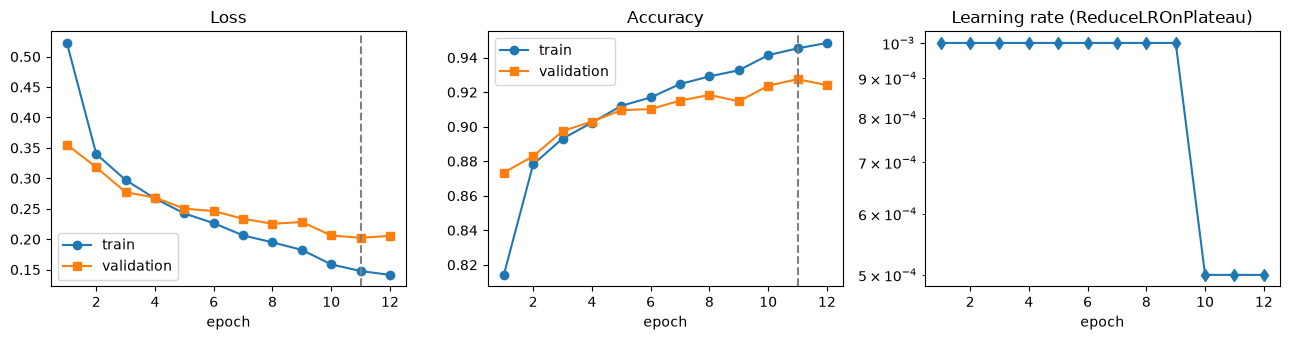

In [38]:
epochs_axis = range(1, epochs_run + 1)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(epochs_axis, cnn_history.history["loss"], "o-", label="train")
axes[0].plot(epochs_axis, cnn_history.history["val_loss"], "s-", label="validation")
axes[0].set(title="Loss", xlabel="epoch")
axes[1].plot(epochs_axis, cnn_history.history["accuracy"], "o-", label="train")
axes[1].plot(epochs_axis, cnn_history.history["val_accuracy"], "s-", label="validation")
axes[1].set(title="Accuracy", xlabel="epoch")
axes[2].plot(epochs_axis, cnn_history.history["learning_rate"], "d-")
axes[2].set(title="Learning rate (ReduceLROnPlateau)", xlabel="epoch", yscale="log")
for ax in axes[:2]:
    ax.axvline(best_cnn_epoch + 1, color="gray", linestyle="--")
    ax.legend()
plt.tight_layout()
plt.show()

### Step 4 — Reload the best checkpoint, then evaluate on the test set once

In [39]:
best_cnn = keras.models.load_model(best_cnn_path)
best_val_loss, best_val_acc = best_cnn.evaluate(x_val_img, y_val, verbose=0)
print(f"reloaded checkpoint on validation: loss {best_val_loss:.4f} | accuracy {best_val_acc:.4f}")

# Model selection is done. Now — and only now — touch the test set, for the CNN and the MLP from Section 3.
test_loss, test_acc = best_cnn.evaluate(x_test_img, y_test, verbose=0)
mlp_test_acc = mlp.evaluate(x_test.reshape(-1, 784).astype("float32") / 255.0, y_test, verbose=0)[1]
print(f"\nTEST accuracy → CNN {test_acc:.4f} | MLP (Section 3) {mlp_test_acc:.4f} | always-guess-one-class baseline {np.bincount(y_test).max() / len(y_test):.2f}")
print(f"→ the CNN makes {1 - (1 - test_acc) / (1 - mlp_test_acc):.0%} fewer test errors than the MLP" if test_acc > mlp_test_acc
      else "→ the CNN did not beat the MLP on this run — train longer or check the setup")

reloaded checkpoint on validation: loss 0.2023 | accuracy 0.9275



TEST accuracy → CNN 0.9212 | MLP (Section 3) 0.8570 | always-guess-one-class baseline 0.10
→ the CNN makes 45% fewer test errors than the MLP


### Step 5 — Prove the saved model reproduces predictions from raw pixels

In [40]:
final_path = OUTPUT_DIR / "fashion_cnn_final.keras"
best_cnn.save(final_path)
served = keras.models.load_model(final_path)
raw_batch = x_test[:256, ..., None]                                              # uint8 pixels, exactly as a client would send
same = np.allclose(best_cnn.predict(raw_batch.astype("float32"), verbose=0), served.predict(raw_batch.astype("float32"), verbose=0), atol=1e-5)
print(f"saved {final_path.name} ({final_path.stat().st_size / 1e6:.2f} MB) — reloaded predictions identical: {same}")
assert same

saved fashion_cnn_final.keras (5.11 MB) — reloaded predictions identical: True


### Step 6 — Error analysis

Shirt        accuracy 0.737
Coat         accuracy 0.864
Pullover     accuracy 0.890
T-shirt/top  accuracy 0.899
Dress        accuracy 0.926
Ankle boot   accuracy 0.963
Sneaker      accuracy 0.976
Bag          accuracy 0.985
Trouser      accuracy 0.986
Sandal       accuracy 0.986

most common mistake: Shirt predicted as T-shirt/top (112 times)


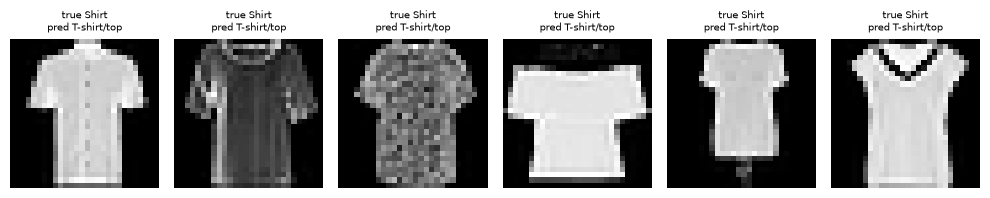

In [41]:
test_pred = best_cnn.predict(x_test_img, verbose=0).argmax(axis=1)
confusion = np.zeros((10, 10), dtype=int)
np.add.at(confusion, (y_test, test_pred), 1)

per_class = confusion.diagonal() / confusion.sum(axis=1)
for idx in np.argsort(per_class):
    print(f"{class_names[idx]:12s} accuracy {per_class[idx]:.3f}")

off_diag = confusion.copy()
np.fill_diagonal(off_diag, 0)
true_cls, pred_cls = np.unravel_index(off_diag.argmax(), off_diag.shape)
print(f"\nmost common mistake: {class_names[true_cls]} predicted as {class_names[pred_cls]} ({off_diag.max()} times)")

wrong_idx = np.flatnonzero((y_test == true_cls) & (test_pred == pred_cls))[:6]
fig, axes = plt.subplots(1, len(wrong_idx), figsize=(10, 2))
for ax, i in zip(np.atleast_1d(axes), wrong_idx):
    ax.imshow(x_test[i], cmap="gray")
    ax.set_title(f"true {class_names[y_test[i]]}\npred {class_names[test_pred[i]]}", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Stretch goals**
1. Add `layers.BatchNormalization()` after each convolution. Does validation accuracy improve, and how does `training=True/False` change BatchNorm's behaviour?
2. Replace `ReduceLROnPlateau` with a cosine schedule: `keras.optimizers.schedules.CosineDecay`.
3. Handle a heavily imbalanced version: keep only 5% of "Shirt" images, train "Shirt vs rest" with `BinaryFocalLoss`, and compare precision/recall with BCE.
4. Export the model with `model.export(..., format="torch")` and load it with `torch.export.load` for inference without Keras.
5. Add `layers.RandomTranslation(0.08, 0.08, fill_mode="constant")` after `Rescaling`. On this torch-backend setup the image augmentation layers made each epoch several times slower — measure the time cost against any validation gain.

### 🗣️ How to talk about this in an interview
- "I kept preprocessing **inside** the Keras model, so the saved `.keras` file takes raw pixels and serving can't drift from training."
- "I split 50k/10k/10k, early-stopped and checkpointed on **validation loss**, and touched the test set once — the CNN reached the test accuracy printed above versus the MLP baseline."
- "`ReduceLROnPlateau` halved the learning rate when validation stalled, and `restore_best_weights=True` rolled back to the best epoch."
- "The error analysis shows the biggest confusions are between visually similar upper-body garments (e.g. shirts vs T-shirts), which points to better features or augmentation rather than just more epochs."
- "I also wrote and unit-tested a backend-agnostic focal loss with `keras.ops`, and caught a shape-dependent discrepancy in a built-in loss by comparing against a NumPy reference."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is Keras 3, and how does it run on different frameworks?**

<details><summary>Show answer</summary>

- **30-second answer:** Keras 3 is a rewrite of Keras as a multi-backend, high-level API: the same models run on JAX, TensorFlow, or PyTorch (OpenVINO for inference). Layers, losses and metrics are written with `keras.ops`, which each backend implements; you choose the backend with `KERAS_BACKEND` before importing Keras.
- **Go deeper:** On the PyTorch backend a Keras model is a `torch.nn.Module`, so it can be used in a hand-written PyTorch loop. Custom code that calls `torch`/`tf`/`jax` directly only works on that backend. The `.keras` format stores the config and weights independently of the backend.
- **❌ Common wrong answer:** "Keras is just part of TensorFlow and needs TensorFlow installed."

</details>

**Q2. Sequential vs Functional vs subclassing — when would you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** Sequential for a single-input, single-output stack. Functional for any static graph — multiple inputs/outputs, skip connections, shared layers — while keeping `summary()`, plotting and easy serialization. Subclassing when the forward pass needs Python control flow or unusual state.
- **Go deeper:** Functional models are validated when you build them (shape errors appear immediately). Subclassed models are only built on first call and need `get_config` for saving.
- **❌ Common wrong answer:** "Sequential can do everything if you add enough layers" — it can't express branches or multiple inputs.

</details>

**Q3. What do `EarlyStopping`, `ModelCheckpoint`, and `ReduceLROnPlateau` do, and what can go wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** EarlyStopping stops training when a monitored validation metric hasn't improved for `patience` epochs; ModelCheckpoint saves the best model to disk; ReduceLROnPlateau lowers the learning rate when progress stalls.
- **Go deeper:** Set `restore_best_weights=True`, otherwise you keep the last (worse) epoch's weights. Monitor a validation metric — monitoring the test set leaks information. Make sure `mode` matches the metric (min for loss, max for accuracy; `auto` infers it from the name).
- **❌ Common wrong answer:** "Early stopping automatically keeps the best model" (not without `restore_best_weights` or a checkpoint).

</details>

**Q4. What does `training=True` vs `training=False` change?**

<details><summary>Show answer</summary>

- **30-second answer:** Layers like Dropout, BatchNormalization and augmentation layers behave differently: during `fit` (`training=True`) dropout drops units, BatchNorm uses batch statistics and updates running averages, and augmentations are random; in `evaluate`/`predict` they are off or use the stored statistics.
- **Go deeper:** When calling a model directly (`model(x)`) the default is inference mode — pass `training=True` explicitly in custom loops. BatchNorm in fine-tuning: frozen layers should run in inference mode.
- **❌ Common wrong answer:** "Dropout is active during prediction too, which is why predictions vary."

</details>

**Q5. `.keras` vs `.weights.h5` vs `model.export()` — which do you use when?**

<details><summary>Show answer</summary>

- **30-second answer:** `.keras` saves the full model (architecture config, weights, optimizer state) for resuming training or sharing; `.weights.h5` saves only weights, so you need the model-building code; `export()` creates an inference artifact (TF SavedModel for TF Serving, LiteRT for mobile, ONNX, OpenVINO, or a torch ExportedProgram).
- **Go deeper:** Custom classes must be registered (`@keras.saving.register_keras_serializable`) or passed via `custom_objects` to reload a `.keras` file. Keras 3 refuses `model.save()` paths without a `.keras` (or legacy `.h5`) extension.
- **❌ Common wrong answer:** "`model.save('my_model')` creates a SavedModel directory" — that was Keras 2 with TensorFlow.

</details>

**Q6. Where does TensorFlow stand today, and when would you still choose Keras/TensorFlow?**

<details><summary>Show answer</summary>

- **30-second answer:** Most new research and open-source LLM tooling is PyTorch-first, with JAX strong inside Google. TensorFlow remains widely deployed, especially for serving (TF Serving), on-device inference (LiteRT, formerly TensorFlow Lite), and in-browser ML (TensorFlow.js). Keras 3 is a good choice for fast standard training, teams already on Google infrastructure (TPUs via JAX), or when you need those deployment targets.
- **Go deeper:** With Keras 3 you can train on one backend and export for another runtime; the risk is custom code that isn't backend-agnostic and the smaller ecosystem for cutting-edge LLM work.
- **❌ Common wrong answer:** "TensorFlow is dead" or "TensorFlow is what everyone uses for LLMs."

</details>

### 💻 Coding

**Q7. Write a custom Keras layer with trainable weights that can be saved and reloaded.**

<details><summary>Show answer</summary>

- **30-second answer:** Subclass `keras.layers.Layer`; store constructor arguments in `__init__`; create weights in `build(input_shape)` with `self.add_weight(shape=..., initializer=...)`; compute in `call()` with `keras.ops`; return the constructor arguments from `get_config()`; decorate with `@keras.saving.register_keras_serializable()`.
- **Go deeper:** Creating weights in `build` lets the input size be inferred. Test it: compare with a built-in layer after copying weights, and do a `.keras` save/load round trip in a unit test.
- **❌ Common wrong answer:** Creating weights in `call()` (new weights every call) or forgetting `get_config`, so loading fails.

</details>

**Q8. Implement binary focal loss. What happens when γ = 0, and how is α applied?**

<details><summary>Show answer</summary>

- **30-second answer:** With `p_t` = probability of the true class: `FL = -α_t (1 - p_t)^γ log(p_t)`, where `α_t = α` for positives and `1 - α` for negatives. `(1 - p_t)^γ` shrinks the loss of well-classified examples. With γ = 0 and no α it's exactly binary cross-entropy; with γ = 0 and α it's class-weighted BCE.
- **Go deeper:** Clip probabilities (or work from logits with log-sigmoid) to avoid `log(0)`. Lin et al. used α = 0.25, γ = 2 for dense object detection. Align shapes inside the loss — `(N,)` labels against `(N, 1)` predictions broadcast to `(N, N)` and training silently fails. Verify against a hand-computed value for your model's output shape.
- **❌ Common wrong answer:** Multiplying both classes by α, or claiming γ = 0 with α = 0.25 equals plain BCE.

</details>

### 🐛 Debugging Scenarios

**Q9. `keras.models.load_model("model.keras")` fails with an error saying it can't locate your custom class. How do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Keras can't rebuild a class it doesn't know. Decorate the class with `@keras.saving.register_keras_serializable()` (and import the module before loading), or pass `custom_objects={"MyLayer": MyLayer}` to `load_model`. Make sure `get_config` returns every constructor argument.
- **Go deeper:** Lambda layers and closures don't serialize safely (loading them requires `safe_mode=False`, which executes arbitrary code) — prefer real layer classes.
- **❌ Common wrong answer:** "Save with the `.h5` extension instead" — the same class lookup is needed.

</details>

**Q10. Your 10-class model trains, but accuracy is mediocre and the loss sits near a strange value. The last layer has `activation="softmax"` and the loss uses `from_logits=True`. What's wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Softmax is applied twice — once in the model, once inside the loss — which squashes the gradients and slows learning (see Pitfall 5). Either output logits with `from_logits=True` (preferred, more numerically stable) or keep softmax and set `from_logits=False`.
- **Go deeper:** Also check label format: integer labels need `SparseCategoricalCrossentropy`, one-hot labels need `CategoricalCrossentropy`. A loss stuck at ln(10) ≈ 2.30 means the model predicts uniformly.
- **❌ Common wrong answer:** "Increase the learning rate" or "add more layers".

</details>

**Q11. Validation accuracy is 95% but the model scores 80% on truly new data. What Keras-specific causes do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Leakage or a biased split: `validation_split` takes the last samples before shuffling (biased if data is ordered); `Normalization.adapt` was run on data that includes validation/test; duplicates between splits; early stopping or tuning done on the test set; or preprocessing done differently at serving time than inside training.
- **Go deeper:** Split explicitly (grouped or time-based when needed), adapt preprocessing on train only, put preprocessing inside the model, and keep a test set you evaluate once.
- **❌ Common wrong answer:** "Just train for more epochs."

</details>

### 🏗️ Design

**Q12. Your company serves models with TF Serving, but new hires want PyTorch. How could Keras 3 help, and what are the risks?**

<details><summary>Show answer</summary>

- **30-second answer:** Write models as Keras 3 code with `keras.ops`, let researchers train on the PyTorch (or JAX) backend, and export a TF SavedModel for the existing TF Serving stack — one codebase, no rewrite of serving. Add CI tests that load the exported artifact and compare predictions with the training model.
- **Go deeper:** Risks: exporting a SavedModel requires TensorFlow in the export environment; backend-specific custom ops break portability; bleeding-edge LLM features may land in PyTorch libraries first. Alternatives: serve PyTorch directly (TorchServe, Triton, vLLM for LLMs) or use ONNX as the interchange format.
- **❌ Common wrong answer:** "Rewrite everything in PyTorch immediately" or "Keras makes backends identical, so no testing is needed."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `keras.Sequential([keras.Input((10,)), layers.Dense(5), layers.Dense(1)]).count_params()`
<details><summary>Answer</summary>

`61` — (10·5 + 5) + (5·1 + 1) = 55 + 6.
</details>

**2.** You set `os.environ["KERAS_BACKEND"] = "jax"` **after** `import keras` in the same process. Which backend is used?
<details><summary>Answer</summary>

The one chosen at import time (here `torch`) — the variable is read when Keras is imported. Restart the kernel and set it first.
</details>

**3.** `layers.Dropout(0.5)` is applied to an array of ones with `training=False`. What comes out?
<details><summary>Answer</summary>

The same array of ones — dropout is only active in training mode (and during training the kept values are scaled by `1 / (1 - rate)` = 2).
</details>

**4.** `fit(x, y, validation_split=0.1)` on 1,000 samples sorted by label. Which samples are used for validation?
<details><summary>Answer</summary>

The **last 100** samples, taken before shuffling — so probably mostly one class.
</details>

**5.** `BinaryFocalLoss(gamma=0.0, alpha=0.25)` on a batch containing only positive examples, compared with binary cross-entropy on the same batch.
<details><summary>Answer</summary>

Exactly `0.25 ×` the BCE value — with γ = 0 the focal term disappears, leaving α-weighted BCE (positives weighted by α).
</details>

## 📚 Resources

### 📖 Official Docs
- [About Keras 3](https://keras.io/getting_started/about/) — what multi-backend Keras is and how to pick a backend
- [The Functional API](https://keras.io/guides/functional_api/) — multi-input/output models and shared layers
- [Making new layers and models via subclassing](https://keras.io/guides/making_new_layers_and_models_via_subclassing/) — `build`, `call`, `get_config`
- [Callbacks API](https://keras.io/api/callbacks/) — EarlyStopping, ModelCheckpoint, ReduceLROnPlateau and more
- [Save, serialize, and export models](https://keras.io/guides/serialization_and_saving/) — the `.keras` format and custom objects
- [Model export for inference](https://keras.io/api/models/model_saving_apis/export/) — SavedModel, ONNX, OpenVINO, LiteRT, torch
- [Ops API](https://keras.io/api/ops/) — the backend-agnostic math functions
- [Image augmentation layers](https://keras.io/api/layers/preprocessing_layers/image_augmentation/) — RandomFlip, RandomTranslation, …
- [Writing a training loop from scratch in PyTorch](https://keras.io/guides/writing_a_custom_training_loop_in_torch/) — Keras models inside a PyTorch loop

### 🎥 Videos
- [TensorFlow — François Chollet - Creating Keras 3](https://www.youtube.com/watch?v=oe6fuxhGVRE) (1 h 05 min) — Keras's creator explains why Keras became multi-backend and how it's designed
- [Google for Developers — Large language models with Keras](https://www.youtube.com/watch?v=TV7qCk1dBWA) (42 min) — Keras 3 running the same code on JAX, PyTorch, or TensorFlow, applied to working with LLMs

### 📄 Papers
- [Lin et al. (2017) — Focal Loss for Dense Object Detection](https://arxiv.org/abs/1708.02002) — where focal loss comes from
- [Xiao et al. (2017) — Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms](https://arxiv.org/abs/1708.07747) — the project dataset

### 📘 Books & Courses
- [Deep Learning with Python — Read Online](https://deeplearningwithpython.io/) — François Chollet's book, free to read online
- [Deep Learning with Python — Chapter 3: Introduction to TensorFlow, PyTorch, JAX, and Keras](https://deeplearningwithpython.io/chapters/chapter03_introduction-to-ml-frameworks/) — how the frameworks relate
- Deployment runtimes mentioned above: [LiteRT (Google AI Edge)](https://ai.google.dev/edge/litert) · [TF Serving](https://www.tensorflow.org/tfx/guide/serving) · [TensorFlow.js](https://www.tensorflow.org/js)

### 🏋️ Practice
- [Kaggle Learn — Intro to Deep Learning](https://www.kaggle.com/learn/intro-to-deep-learning) — short hands-on Keras exercises
- [Keras code examples](https://keras.io/examples/) — hundreds of runnable, focused examples to adapt

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API |
|---|---|---|
| Backend | choose the engine | `os.environ["KERAS_BACKEND"] = "torch"` **before** `import keras` |
| Backend-agnostic math | portable ops | `keras.ops.matmul / softmax / where / mean` |
| Build models | three styles | `keras.Sequential`, `keras.Model(inputs, outputs)`, subclass `keras.Model` |
| Train | built-in loop | `compile(optimizer, loss, metrics)` → `fit(validation_data=…)` → `evaluate` → `predict` |
| Callbacks | control training | `EarlyStopping(restore_best_weights=True)`, `ModelCheckpoint(save_best_only=True)`, `ReduceLROnPlateau` |
| Preprocessing | data prep inside the model | `Normalization.adapt(train)`, `Rescaling`, `RandomFlip/Translation/Rotation` |
| Custom layer | new building block | `build` + `add_weight`, `call` with `keras.ops`, `get_config`, `@register_keras_serializable` |
| Custom loss | new objective | subclass `keras.losses.Loss` → `call(y_true, y_pred)` returns per-sample loss |
| Focal loss | focus on hard examples | `-α_t (1 - p_t)^γ log p_t`; γ=0 & α=None → BCE |
| Save / load | persistence | `model.save("m.keras")`, `keras.models.load_model`, `save_weights("m.weights.h5")`, `export(format=…)` |
| Keras ↔ PyTorch | translate | `call` ↔ `forward`, `fit` ↔ hand-written loop, `.keras` ↔ `state_dict` |

## ➡️ What's Next

**[05 NLP · Classical NLP](../05_NLP/01_Classical_NLP.ipynb)** — with deep-learning tools in hand, turn to text: tokenization, TF-IDF, and word vectors — the classic NLP toolkit that still powers search and strong baselines before transformers.